In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"..\data\raw\IT Support Ticket Data.csv")

In [6]:
df.head()

,Unnamed: 0,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [7]:
df['word_count'] = df['Body'].astype(str).apply(lambda text: len(text.split()))

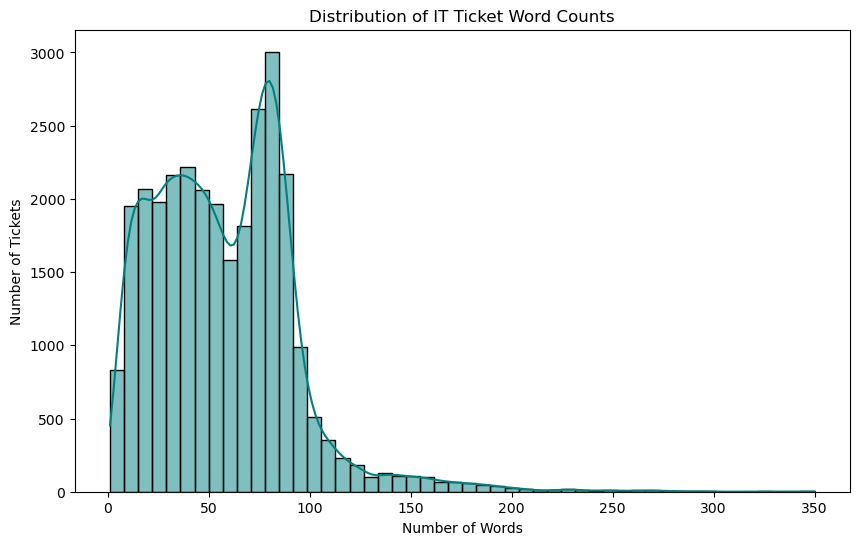

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', bins=50, kde=True, color='teal')
plt.title("Distribution of IT Ticket Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")
plt.show()

In [13]:
p95_length = int(df['word_count'].quantile(0.95))
print(f"--- Tokenization Recommendation ---")
print(f"95% of tickets are shorter than: {p95_length} words.")

standard_lengths = [64, 128, 256, 512]
recommended_max_len = next((length for length in standard_lengths if length >= p95_length), 512)

print(f"Recommendation: Set your Huggingface tokenizer `max_length={recommended_max_len}`")
print(f"This ensures fast training while safely keeping the context for 95%+ of your data.")

--- Tokenization Recommendation ---
95% of tickets are shorter than: 110 words.
Recommendation: Set your Huggingface tokenizer `max_length=128`
This ensures fast training while safely keeping the context for 95%+ of your data.


C:\temp_tmp\ipykernel_18172\1247855524.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Department', order=category_counts.index, palette='mako')


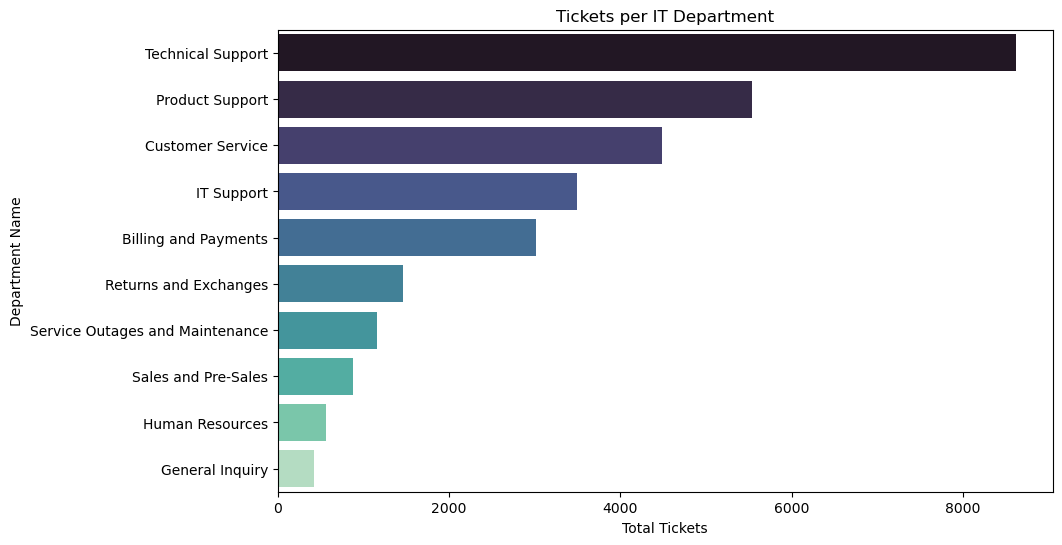

In [14]:
category_counts = df['Department'].value_counts()

# --- 3. Visualize the Balance ---
plt.figure(figsize=(10, 6))
# We use the index of value_counts to automatically sort the bars from highest to lowest
sns.countplot(data=df, y='Department', order=category_counts.index, palette='mako')
plt.title("Tickets per IT Department")
plt.xlabel("Total Tickets")
plt.ylabel("Department Name")
plt.show()

In [16]:
total_tickets = len(df)
print("--- Class Imbalance Report ---")
category_percentages = (category_counts / total_tickets) * 100

for category, percentage in category_percentages.items():
    print(f"{category}: {percentage:.2f}% of data")
    
    # Trigger a warning if a class has less than 5% of the total data
    if percentage < 5.0:
        print(f"  -> ⚠️ WARNING: '{category}' has too little data. The model may struggle to learn this class.")

print("\nRecommendation: If you see warnings above, consider using 'Stratified Sampling' when splitting your data, or apply 'Class Weights' during model training!")

--- Class Imbalance Report ---
Technical Support: 29.06% of data
Product Support: 18.68% of data
Customer Service: 15.12% of data
IT Support: 11.80% of data
Billing and Payments: 10.18% of data
Returns and Exchanges: 4.95% of data
  -> ⚠️ WARNING: 'Returns and Exchanges' has too little data. The model may struggle to learn this class.
Service Outages and Maintenance: 3.90% of data
  -> ⚠️ WARNING: 'Service Outages and Maintenance' has too little data. The model may struggle to learn this class.
Sales and Pre-Sales: 2.98% of data
  -> ⚠️ WARNING: 'Sales and Pre-Sales' has too little data. The model may struggle to learn this class.
Human Resources: 1.92% of data
  -> ⚠️ WARNING: 'Human Resources' has too little data. The model may struggle to learn this class.
General Inquiry: 1.41% of data
  -> ⚠️ WARNING: 'General Inquiry' has too little data. The model may struggle to learn this class.

Recommendation: If you see warnings above, consider using 'Stratified Sampling' when splitting you

--- 1. Extracting and Cleaning Words ---
--- 2. Filtering Stopwords ---
--- 3. Counting Frequencies ---
--- 4. Visualizing the Vocabulary ---


C:\temp_tmp\ipykernel_18172\2195013081.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_df, x='Frequency', y='Word', palette='magma')


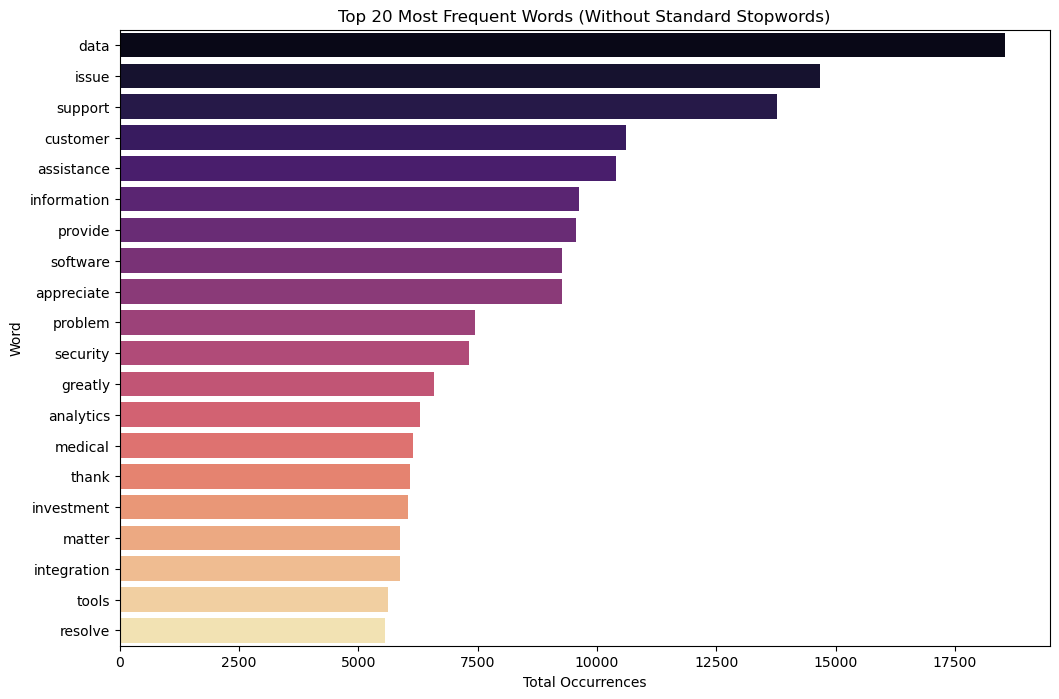

--- 🧐 Domain-Specific Stopword Review ---
Review the chart above.
If you see generic IT support words dominating the chart (e.g., 'hello', 'thanks', 'ticket', 'please', 'help', 'issue', 'regards'), they are NOT helping your model learn!

Action Item: Add those specific words to your custom IT_STOPWORDS list in your `src/data/preprocess.py` script so they are removed before training.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Assuming 'df' is already loaded
# df = pd.read_csv('../data/raw/it_support_tickets.csv')

print("--- 1. Extracting and Cleaning Words ---")
# Combine all tickets into one massive lowercase string
all_text = " ".join(df['Body'].dropna().astype(str).tolist()).lower()

# Use Regex to extract only words containing alphabetic characters (length >= 2)
# This automatically strips out punctuation and numbers
words = re.findall(r'\b[a-z]{2,}\b', all_text)

print("--- 2. Filtering Stopwords ---")
# Keep only words that are NOT in the standard English stopword list
valid_words = [word for word in words if word not in ENGLISH_STOP_WORDS]

print("--- 3. Counting Frequencies ---")
word_frequencies = Counter(valid_words)
top_20_words = word_frequencies.most_common(20)

# Convert to DataFrame for easy plotting
top_20_df = pd.DataFrame(top_20_words, columns=['Word', 'Frequency'])

print("--- 4. Visualizing the Vocabulary ---")
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_df, x='Frequency', y='Word', palette='magma')
plt.title("Top 20 Most Frequent Words (Without Standard Stopwords)")
plt.xlabel("Total Occurrences")
plt.ylabel("Word")
plt.show()

# --- 5. Human-in-the-Loop Decision ---
print("--- 🧐 Domain-Specific Stopword Review ---")
print("Review the chart above.")
print("If you see generic IT support words dominating the chart (e.g., 'hello', 'thanks', 'ticket', 'please', 'help', 'issue', 'regards'), they are NOT helping your model learn!")
print("\nAction Item: Add those specific words to your custom IT_STOPWORDS list in your `src/data/preprocess.py` script so they are removed before training.")